# **Setup**

In [3]:
from pathlib import Path

import sys
import pandas as pd
import numpy as np
import IPython
import matplotlib as mpl
from IPython.display import display, Markdown, Latex, HTML, IFrame, JSON, Code, Image, YouTubeVideo, clear_output
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print( f"Python {sys.version}" )
print( f"Pandas {pd.__version__}" )
print( f"NumPy {np.__version__}" )
print( f"IPython {IPython.__version__}" )
print( f"Matplotlib {mpl.__version__}" )

Python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Pandas 2.2.3
NumPy 2.1.3
IPython 7.34.0
Matplotlib 3.10.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Number of Amazon and Starbuck Store in Thailand**

## Loading, Reshape, Set the color

In [5]:
df_store = pd.read_csv('/content/drive/MyDrive/DADS5001/Amazon_Starbucks_Thailand_by_year.csv')
pivot = df_store.pivot_table(index='Year', columns='Brand', values='Number_of_Stores', aggfunc='mean')
colors = {'Cafe Amazon': 'tab:blue', 'Starbucks': 'tab:red'}

## Findind % change around the 2010 crossover point

In [6]:
cross_year = 2010
growth_lines = []
for brand in pivot.columns:
    series = pivot[brand].dropna()
    before_year = series.index[series.index <= cross_year].max()
    after_year = series.index[series.index >= cross_year].min()
    next_after = series.index[series.index > cross_year].min() if (series.index > cross_year).any() else None

    if before_year != after_year:
        pct_into = (series[after_year] - series[before_year]) / series[before_year] * 100
        growth_lines.append(
            f"{brand}: {before_year}→{after_year}  {series[before_year]:,.0f}→{series[after_year]:,.0f}  (+{pct_into:.1f}%)"
        )
    if cross_year in series.index and next_after is not None:
        pct_out = (series[next_after] - series[cross_year]) / series[cross_year] * 100
        growth_lines.append(
            f"{brand}: {cross_year}→{next_after}  {series[cross_year]:,.0f}→{series[next_after]:,.0f}  (+{pct_out:.1f}%)"
        )

summary_text = "Growth around 2010 crossover:\n" + "\n".join(growth_lines)
#print(summary_text)

## Plot

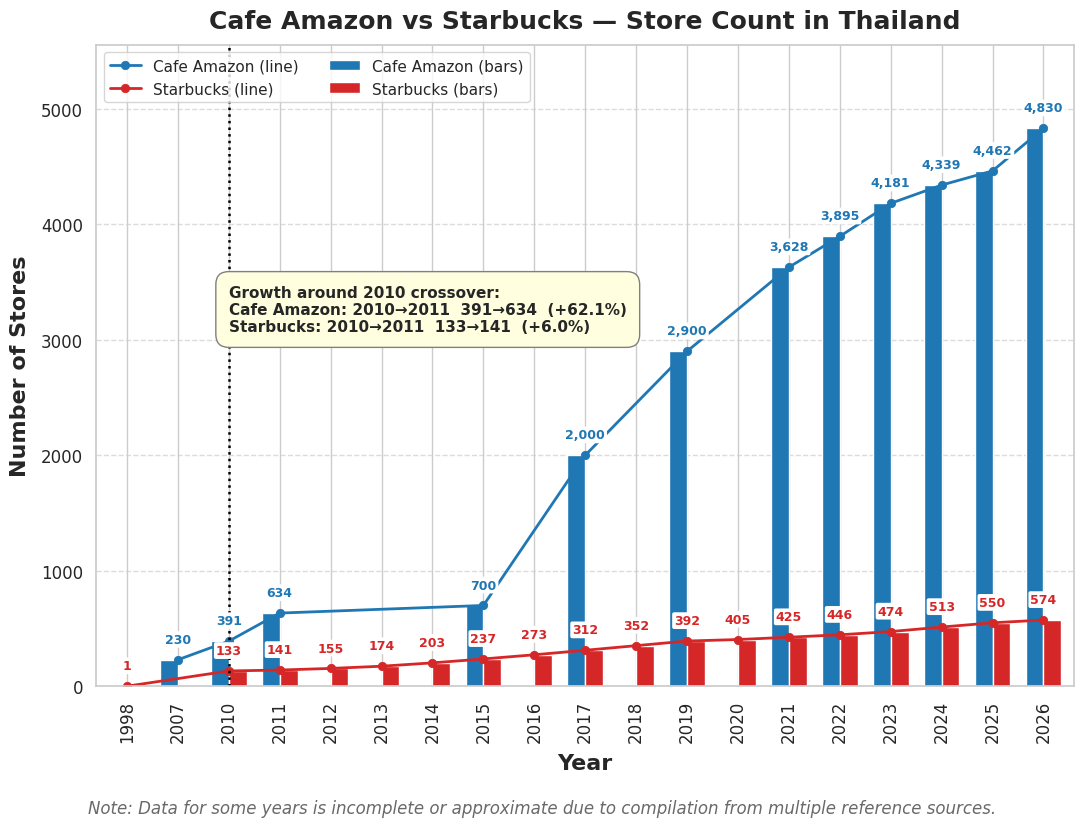

In [15]:
# Bars
ax = pivot.plot(kind='bar', figsize=(11, 8), alpha=1, width=0.7,
                 color=[colors[c] for c in pivot.columns])

# Overlay lines & labels
line_handles = []
for brand in pivot.columns:
    series = pivot[brand].dropna()
    x_pos = [pivot.index.get_loc(idx) for idx in series.index]

    line, = ax.plot(x_pos, series.values, marker='o', linewidth=2,
                     color=colors[brand], markeredgewidth=0.6)
    line_handles.append(line)

    for x, val in zip(x_pos, series.values):
        ax.annotate(f'{int(val):,}', (x, val),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color=colors[brand],
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=1))

# Mark the 2010 crossover point with dot line
if cross_year in pivot.index:
    x_cross = pivot.index.get_loc(cross_year)
    ax.axvline(x_cross, color='black', linestyle=':', linewidth=1.8, alpha=1)

# Set position of % change
x_idx = pivot.index.get_loc(2002) if 2002 in pivot.index else 2
y_val = pivot.max().max() * 0.72

ax.text(x_idx, y_val, summary_text,
        fontsize=11, fontweight='bold', ha='left', va='top',
        bbox=dict(boxstyle="round,pad=0.85", fc="lightyellow", ec="gray", alpha=1))

# Combined legend
bar_handles, _ = ax.get_legend_handles_labels()   # only the 2 labeled bar containers
handles = line_handles + bar_handles
labels = [f'{c} (line)' for c in pivot.columns] + [f'{c} (bars)' for c in pivot.columns]
ax.legend(handles, labels, loc='upper left', ncol=2)

# Styling titles, axes
ax.set_title('Cafe Amazon vs Starbucks — Store Count in Thailand', fontsize=18, pad=12, fontweight="bold")
ax.set_xlabel('Year', labelpad=8, fontsize=16, fontweight="bold")
ax.set_ylabel('Number of Stores', labelpad=8, fontsize=16, fontweight="bold")
ax.set_xticklabels(pivot.index, rotation=90, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, pivot.max().max() * 1.15)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add footnote
footnote = 'Note: Data for some years is incomplete or approximate due to compilation from multiple reference sources.'
plt.figtext(0.5, -0.01, footnote, wrap=True, ha='center', va='top', fontsize=12, style='italic', color='dimgray')

plt.tight_layout()
plt.savefig('store_counts_combined.png', dpi=300)
plt.show()

เนื่องจากไม่สามารถหาข้อมูลที่เป็นสถิติจำนวนสาขาของ Cafe Amazon และ Starbucks ทั้งหมดได้ จึงทำให้มีข้อมูลขาดหายในบางปี และข้อมูลตัวเลขที่แสดงในกราฟของบางปีอาจจะคลาดเคลื่อนเล็กน้อย เนื่องจากมีการสืบค้นข้อมูลจากหลายแหล่งอ้างอิง